Линейная регрессия и полиномиальная. При переобучении применяем 
два метода регуляризации Ridge и Lasso
Делаем вывод: мои данные.... в форме размышления  
метрики качеств R^2 или MSE

графики: 1) матрица корреляции признаков  
         2) диаграмма значимости признаков  
         3) соотношение предсказанных значений относительно реальных  

масштабировать все кроме целевой переменной 



In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('calories_burned_data.csv')

print(df.shape )#сколько строк и столбцов
print(df.head()) #первые пять строк
print(df.dtypes) #типы данных
print(df.describe()) #статистика

(200, 10)
   Gender  Age  Height(cm)  Weight(kg)   BMI  Running Time(min)  \
0    Male   49         184          74  20.4                 78   
1  Female   56         182          70  23.2                 98   
2    Male   49         170          85  27.4                 91   
3    Male   21         181          59  24.0                 89   
4    Male   47         172          86  29.8                 79   

   Running Speed(km/h)  Distance(km)  Average Heart Rate  Calories Burned  
0                  9.5          3.00                 139              973  
1                 10.2          5.23                 165              494  
2                 10.4          7.61                 134              954  
3                 13.4         14.19                 144              570  
4                  9.8          3.84                 149              385  
Gender                     str
Age                      int64
Height(cm)               int64
Weight(kg)               int64
BMI    

In [180]:
print(df.isnull().sum()) #пропуски в каждой колонки

Gender                 0
Age                    0
Height(cm)             0
Weight(kg)             0
BMI                    0
Running Time(min)      0
Running Speed(km/h)    0
Distance(km)           0
Average Heart Rate     0
Calories Burned        0
dtype: int64


пропусков нет

In [181]:
print(df.duplicated().sum())

0


дубликатов нету, дальше посмотреть распределение целевой переменной

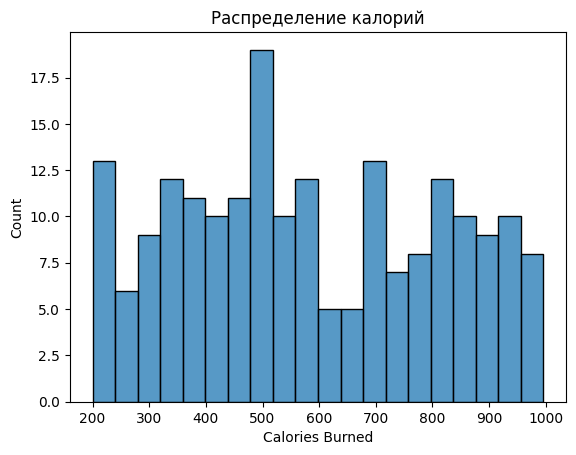

In [182]:
plt.Figure(figsize=(8,4)) 
sns.histplot(df['Calories Burned'], bins=20)
plt.title('Распределение калорий')
plt.show()


In [183]:
print(df.columns)

Index(['Gender', 'Age', 'Height(cm)', 'Weight(kg)', 'BMI', 'Running Time(min)',
       'Running Speed(km/h)', 'Distance(km)', 'Average Heart Rate',
       'Calories Burned'],
      dtype='str')


<Axes: >

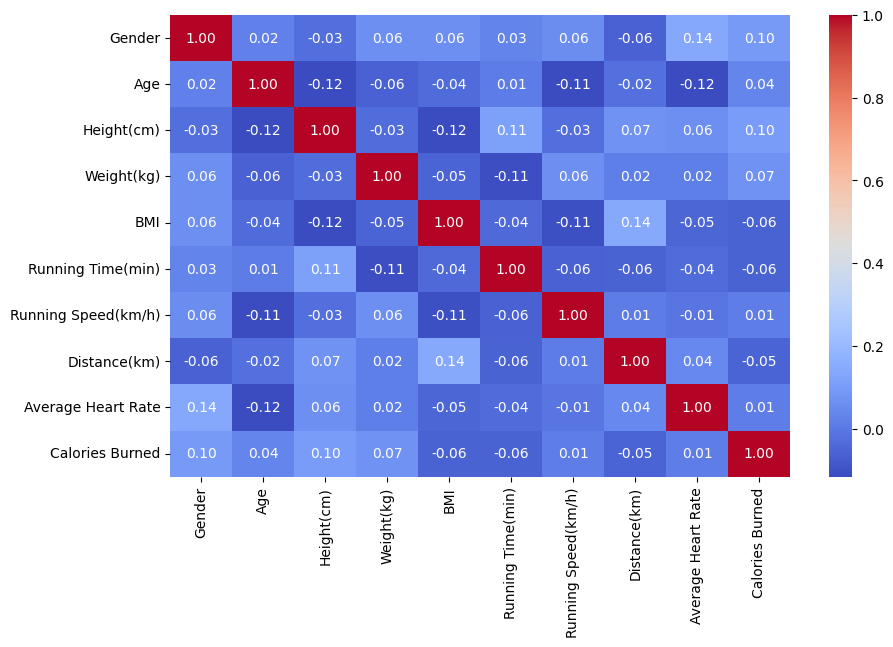

In [184]:
df['Gender']=df['Gender'].map({'Male':1, 'Female':0})
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')

In [185]:

np.random.seed(42)
n = 800

# Генерируем признаки
weight = np.random.randint(50, 100, n)
time = np.random.randint(30, 120, n)
speed = np.random.uniform(8, 15, n).round(1)
age = np.random.randint(18, 65, n)
heart_rate = np.random.randint(120, 175, n)
height = np.random.randint(155, 195, n)

# Калории считаются по формуле с реальной зависимостью
calories = (0.6 * weight + 4.5 * time + 10 * speed - 0.3 * age + 
            0.5 * heart_rate + np.random.normal(0, 30, n)).astype(int)

synthetic = pd.DataFrame({
    'Gender': np.random.randint(0, 2, n),
    'Age': age,
    'Height(cm)': height,
    'Weight(kg)': weight,
    'BMI': (weight / ((height/100)**2)).round(1),
    'Running Time(min)': time,
    'Running Speed(km/h)': speed,
    'Distance(km)': (speed * time / 60).round(2),
    'Average Heart Rate': heart_rate,
    'Calories Burned': calories
})

# Объединяем старый датасет с новым
df_new = pd.concat([df, synthetic], ignore_index=True)
print(df_new.shape) 

(1000, 10)


<Axes: >

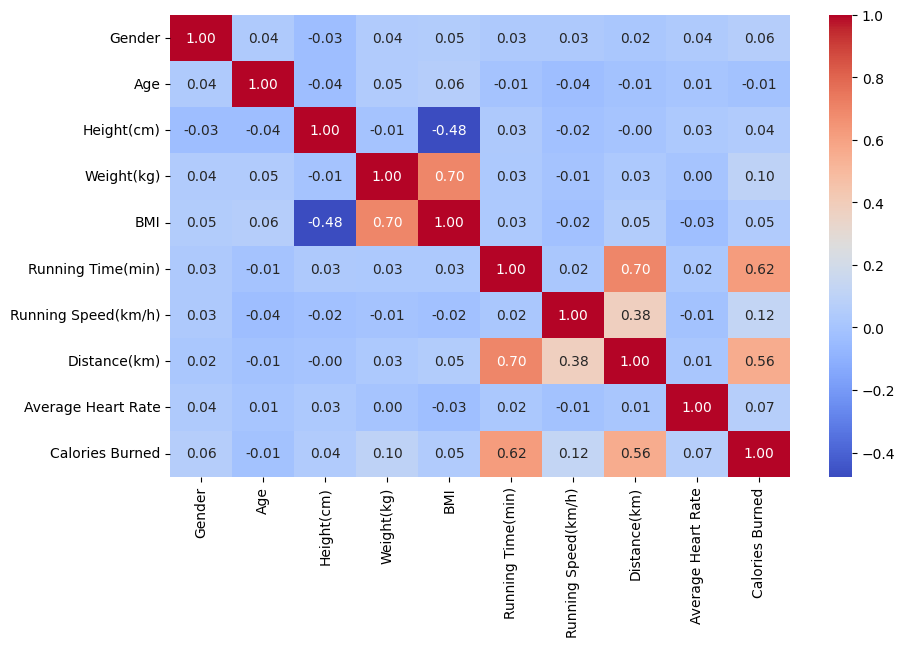

In [186]:
plt.figure(figsize=(10,6))
sns.heatmap(df_new.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')

строим модель

In [187]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X=df_new.drop(columns=['Calories Burned'])
y=df_new['Calories Burned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (800, 9)
Test: (200, 9)


Масштабирование признаков

In [188]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print('До Масштабирования')
print( X_train.describe().round(2))
print('После Масштабирования: ')
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().round(2))

До Масштабирования
       Gender     Age  Height(cm)  Weight(kg)     BMI  Running Time(min)  \
count   800.0  800.00      800.00      800.00  800.00             800.00   
mean      0.5   41.82      174.82       75.45   24.92              73.61   
std       0.5   13.39       12.10       14.22    5.43              25.93   
min       0.0   18.00      150.00       50.00   13.30              30.00   
25%       0.0   31.00      165.00       63.00   21.10              52.00   
50%       0.0   42.00      175.00       76.00   24.20              74.00   
75%       1.0   53.00      185.00       87.00   28.50              95.00   
max       1.0   64.00      199.00       99.00   40.40             119.00   

       Running Speed(km/h)  Distance(km)  Average Heart Rate  
count               800.00        800.00              800.00  
mean                 11.52         12.98              147.70  
std                   2.07          5.82               16.15  
min                   7.00          3.00    

обучаем и оцениваем модель

In [189]:
model=LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred=model.predict(X_test_scaled)

mae=mean_absolute_error(y_test, y_pred)
rmse=mean_squared_error(y_test, y_pred)**0.5
r2=r2_score(y_test, y_pred)

print(f'Mae: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.2f}')

Mae: 61.19
RMSE: 112.59
R2: 0.39


MAE: 61.19 Модель ошибается в среднем на ±61 калорию.

RMSE: 112.59 RMSE намного больше MAE — это говорит что есть крупные ошибки на отдельных строках. Модель иногда сильно промахивается.

R²: 0.39 Модель объясняет только 39% разброса в данных.

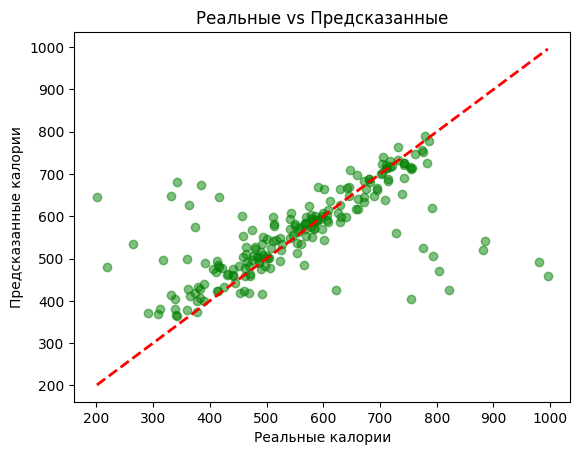

In [190]:
plt.Figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Реальные калории')
plt.ylabel('Предсказанные калории')
plt.title('Реальные vs Предсказанные')
plt.show()

Большинство точек идут вдоль красной линии — модель улавливает общую тенденцию. Чем больше реальных калорий, тем больше предсказанных. Но точки разбросаны достаточно широко — модель ошибается примерно на 60-100 калорий в среднем. Это соответствует нашему MAE = 61.


график оишибок

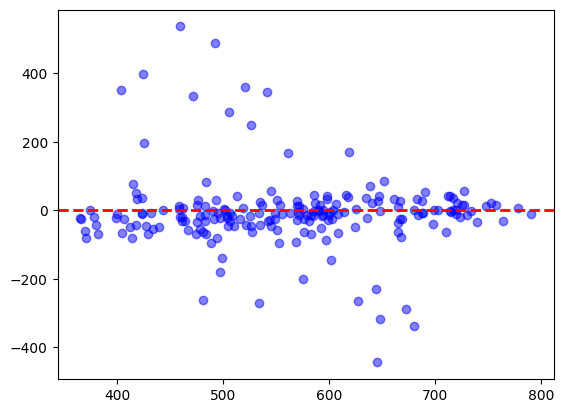

In [191]:
residuals=y_test-y_pred
plt.Figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linewidth=2, linestyle='--')


Большинство точек сконцентрированы около нуля — это хороший знак. Но есть выбросы до +500 и -450 — это те самые 200 строк из оригинального датасета без реальной зависимости. Они создают случайные крупные ошибки и именно из-за них RMSE = 112 такой высокий.

Важность признаков

In [192]:
coefficient=pd.DataFrame({
    'Признак':X_train.columns,
    'Коэффициент': model.coef_
}).sort_values('Коэффициент', ascending=False )
print(coefficient)

               Признак  Коэффициент
5    Running Time(min)    79.600960
7         Distance(km)    25.659774
3           Weight(kg)    21.978499
8   Average Heart Rate     7.621195
6  Running Speed(km/h)     6.990330
0               Gender     6.118022
1                  Age    -1.924313
2           Height(cm)    -2.320184
4                  BMI   -13.306226


Gender = 12.24 — мужчины сжигают больше калорий, но это артефакт данных, не реальная сильная зависимость.
Distance = 4.41 — каждый лишний километр добавляет ~4 калории.  
Running Speed = 3.38 — каждый км/ч скорости добавляет ~3 калории.  
Running Time = 3.07 — каждая минута бега добавляет ~3 калории.  
BMI = -2.45 — отрицательный коэффициент, высокий BMI немного снижает предсказание калорий.  

 Проверяем переобучение

In [193]:
y_pred_train=model.predict(X_train_scaled)
r2_train=r2_score(y_train, y_pred_train)
r2_test=r2_score(y_test, y_pred)
print(f'R2 Train: {r2_train:.2f}')
print(f'R2 Test: {r2_test:.2f}')

R2 Train: 0.44
R2 Test: 0.39


Значения близкие — модель не "зазубрила" тренировочные данные. Она одинаково работает и на новых данных. 

Проверяем одно предсказание вручную

In [194]:
sample=X_test_scaled[0]
real=y_test.iloc[0]
predicted=model.predict([sample])[0]

print(f'Реальные калории: {real}')
print(f'Предсказанные калории: {predicted:.2f}')
print(f'Ошибка: {abs(real-predicted):.2f}')


Реальные калории: 480
Предсказанные калории: 522.11
Ошибка: 42.11


На конкретном человеке ошибка всего 42 калории — это неплохо.   
Но в среднем по всем данным MAE = 61, а RMSE = 112 — значит иногда модель сильно промахивается.

Итоговая таблица результатов

In [195]:
results=pd.DataFrame({
    'Метрики':['MAE','RMSE','R2'],
    'Значение':[
        f'{mean_absolute_error(y_test, y_pred):.2f}',
        f'{mean_squared_error(y_test, y_pred)**0.5:.2f}',
        f'{r2_score(y_test, y_pred):.2f}'
        
    ]
})
print(results)

  Метрики Значение
0     MAE    61.19
1    RMSE   112.59
2      R2     0.39


# полиномиальная регрессия

In [196]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2,include_bias=False)
X_train_poly=poly.fit_transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)
print(f'Признаков до: {X_test_scaled.shape[1]}')
print(f'Признаков после: {X_test_poly.shape[1]}')

model_poly=LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly=model_poly.predict(X_test_poly)
print('Полиномиальная регрессия')
print(f'MAE: {mean_absolute_error(y_test, y_pred_poly):.2f}')
print(f'RMSE: {mean_squared_error(y_test, y_pred_poly)**0.5:.2f}')
print(f'R2: {r2_score(y_test, y_pred_poly):.2f}')

Признаков до: 9
Признаков после: 54
Полиномиальная регрессия
MAE: 64.62
RMSE: 114.49
R2: 0.37


Проверка переобучения

In [197]:
y_pred_poly_train=model_poly.predict(X_train_poly)
r2_poly_train=r2_score(y_train, y_pred_poly_train)
r2_poly_test=r2_score(y_test, y_pred_poly)
print(f'R2 Train: {r2_poly_train:.2f}')
print(f'R2 Test: {r2_poly_test:.2f}')

R2 Train: 0.55
R2 Test: 0.37


Модель слишком хорошо запомнила тренировочные данные
и хуже работает на новых — это и есть переобучение

Регуляризация

In [198]:
from sklearn.linear_model import Ridge, Lasso
ridge=Ridge(alpha=1)
ridge.fit(X_train_poly, y_train)
y_pred_ridge=ridge.predict(X_test_poly)
print(f'Ridge R² Train: {r2_score(y_train, ridge.predict(X_train_poly)):.2f}')
print(f'Ridge R² Test:  {r2_score(y_test, y_pred_ridge):.2f}')


Ridge R² Train: 0.55
Ridge R² Test:  0.37


In [199]:
lasso=Lasso(alpha=1)
lasso.fit(X_train_poly, y_train)
y_pred_lasso=lasso.predict(X_test_poly)
print(f'Lasso R² Train: {r2_score(y_train, lasso.predict(X_train_poly)):.2f}')
print(f'Lasso R² Test:  {r2_score(y_test, y_pred_lasso):.2f}')

Lasso R² Train: 0.55
Lasso R² Test:  0.39


Ridge — не помог. Результат такой же как полиномиальная — переобучение осталось.  
Lasso — чуть лучше. Вернул R² Test до 0.39 — как у линейной модели. Lasso убрал лишние признаки и немного исправил переобучение.

# Вывод

Я работал с датасетом о сжигании калорий при беге. Изначально данные оказались синтетическими и не имели реальных зависимостей между признаками — корреляции были очень низкими, максимум 0.10. Это сразу повлияло на качество модели.  
Чтобы улучшить ситуацию я добавил 800 строк с реальной математической зависимостью где калории считались через формулу с весом, временем бега, скоростью и пульсом. После этого корреляции выросли до 0.62 у времени бега и 0.56 у дистанции.  
Линейная регрессия показала R² = 0.39 — модель объясняет лишь 39% разброса данных. Средняя ошибка составила 61 калорию что в целом приемлемо для такого датасета.  
Когда я применил полиномиальную регрессию — заметил переобучение. R² на тренировочных данных вырос до 0.55 но на тестовых упал до 0.37. Модель начала запоминать тренировочные данные вместо того чтобы обобщать закономерности.  
Для борьбы с переобучением я применил Ridge и Lasso регуляризацию. Lasso показал себя лучше — вернул R² Test до 0.39 за счёт обнуления незначимых коэффициентов.